# Start training Random Forest

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Load the cleaned data
data = pd.read_csv('../data/processed.csv')
# Define features and target variable
X = data.drop('churn', axis=1)
y = data['churn']
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [25]:
# Initialize the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
# Train the model
rf.fit(X_train, y_train)
# Evaluate the model
y_pred = rf.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1593
           1       0.75      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.74      2000
weighted avg       0.85      0.86      0.84      2000

[[1533   60]
 [ 223  184]]


Since the dataset is imbalanced, we can see how the model with the default parameters performs detecting correctly the customers that won't churn, but it fails to detect the customers that will churn. This is a common problem when dealing with imbalanced datasets.

A **false negative (loose case) is more costly** than a false positive (tight case) in this scenario, since we want to identify as many customers that will churn as possible, even if it means that we will have some false positives. We will prioritize recall over precision in this case, since we want to minimize the number of false negatives.

## 01. Grid Search

In [26]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
# Define the parameter grid for Grid Search
param_grid = {
    'class_weight': ['balanced', 'balanced_subsample', None],
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [5,10,15],
    'min_samples_leaf': [2,4,6],
    'max_features': ['sqrt', 'log2']
}
# Initialize Grid Search
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,scoring='roc_auc',cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), n_jobs=-1, verbose=0)
# Fit Grid Search to the training data
grid_search.fit(X_train, y_train)
# Best parameters from Grid Search
print("Best Parameters:", grid_search.best_params_)
# Train the model with the best parameters
best_rf = grid_search.best_estimator_
# Evaluate the model with the best parameters
y_pred_best = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_best))
print("_" * 50)
print("ROC AUC Score:", grid_search.best_score_)
print("_" * 50)
print(confusion_matrix(y_test, y_pred_best))

Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 15, 'n_estimators': 300}
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1593
           1       0.57      0.67      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.77      0.75      2000
weighted avg       0.84      0.83      0.84      2000

__________________________________________________
ROC AUC Score: 0.8588273251726364
__________________________________________________
[[1388  205]
 [ 133  274]]


In [27]:
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]
    

In [28]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.8617785736429804


In [29]:
from sklearn.model_selection import cross_val_score
# Cross-validation scores for the best model
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), scoring='roc_auc') 
print("Cross-validation ROC AUC scores:", cv_scores)
print("Mean ROC AUC score:", cv_scores.mean())

Cross-validation ROC AUC scores: [0.85775202 0.86897218 0.87280774 0.83966494 0.85493976]
Mean ROC AUC score: 0.8588273251726364


In [31]:
import joblib
### Save model
joblib.dump(best_rf, '../models/best_rf_model.pkl')

['../models/best_rf_model.pkl']

## Visualization of the results

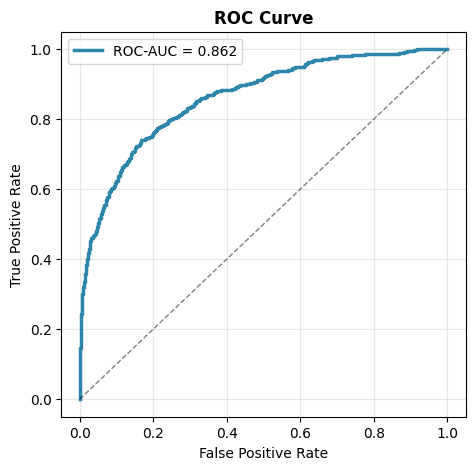

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.3)
ax = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)
ax.plot(fpr, tpr, linewidth=2.5, label=f'ROC-AUC = {roc_auc:.3f}', color='#2E86AB')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

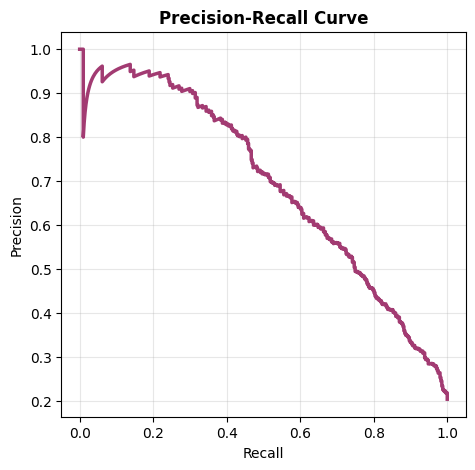

In [33]:
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.3)
ax = fig.add_subplot(gs[0, 0])
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
ax.plot(recall, precision, linewidth=2.5, color='#A23B72')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)


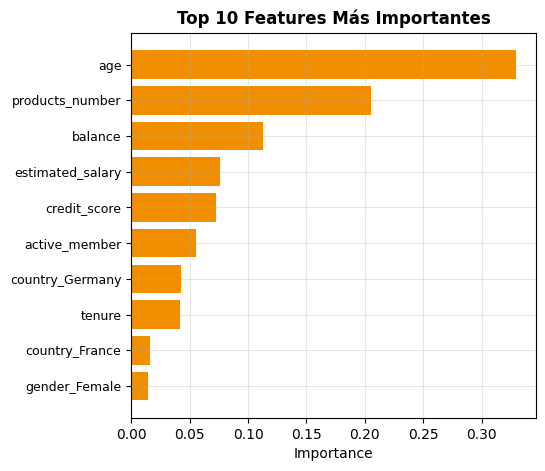

In [34]:
# 4. Feature Importance
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.3)
ax = fig.add_subplot(gs[0,0])
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False).head(10)
    
ax.barh(range(len(feature_importance)), feature_importance['importance'], color='#F18F01')
ax.set_yticks(range(len(feature_importance)))
ax.set_yticklabels(feature_importance['feature'], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('Top 10 Features Más Importantes', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3)

# XGBoost

In [35]:
import xgboost as xgb
from sklearn.model_selection import (
    train_test_split, 
    GridSearchCV, 
    StratifiedKFold,
    cross_val_score
)
from sklearn.metrics import (
    roc_auc_score, 
    classification_report, 
    confusion_matrix,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve
)

In [36]:
  #Calculate scale_pos_weight 
n_negativa = (y_train == 0).sum()
n_positiva = (y_train == 1).sum()
scale_pos_weight = n_negativa / n_positiva

In [37]:
    # Grid con parámetros específicos de XGBoost
    param_grid = {
        # Tasa de aprendizaje
        'learning_rate': [0.05, 0.1],
        
        # Profundidad (XGBoost usa árboles más profundos)
        'max_depth': [5, 6, 7],
        
        # Min child weight (mínimo peso en hoja)
        'min_child_weight': [1, 3],
        
        # Regularización L2
        'reg_lambda': [0.5, 1.0],
        
        # Submuestreo de muestras
        'subsample': [0.8, 0.9],
        
        # Submuestreo de features
        'colsample_bytree': [0.8, 0.9],
        
        # Número de árboles (XGBoost lo maneja diferente)
        'n_estimators': [100, 200]
    }

In [38]:
# XGBoost classifier con scale_pos_weight
xgb_base = xgb.XGBClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight,  # Para desbalanceo
    tree_method='hist',                 # Método más rápido
    n_jobs=-1,
    verbosity=0
)



In [39]:
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    verbose=2,
    return_train_score=True)
grid_search.fit(X_train, y_train)



Fitting 5 folds for each of 192 candidates, totalling 960 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=100, reg_lambda=0.5, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=100, reg_lambda=0.5, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=100, reg_lambda=0.5, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=100, reg_lambda=0.5, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=100, reg_lambda=0.5, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=100, reg_lambda=0.5, subsample=0.9; total time=   0.0s
[CV] END colsample_bytree

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 0.9], 'learning_rate': [0.05, 0.1], 'max_depth': [5, 6, ...], 'min_child_weight': [1, 3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computatio

In [40]:
#best Model
best_xgb = grid_search.best_estimator_
best_params = grid_search.best_params_


# Grid Search Results
print("Best Parameters:", grid_search.best_params_)
print("Best ROC AUC Score (CV):", grid_search.best_score_)
print("=" * 50)
print("Confusion Matrix:")
print(confusion_matrix(y_test, best_xgb.predict(X_test)))
print("=" * 50)
print(classification_report(y_test, best_xgb.predict(X_test)))

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 200, 'reg_lambda': 1.0, 'subsample': 0.8}
Best ROC AUC Score (CV): 0.864866947250821
Confusion Matrix:
[[1314  279]
 [ 104  303]]
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      1593
           1       0.52      0.74      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



In [ ]:
def train_with_early_stopping(X_train, y_train, X_test, y_test, best_params, scale_pos_weight):
    """Entrena modelo con early stopping (adicional a GridSearch)."""
    
    # Preparar eval set (10% de training)
    X_train_part, X_eval, y_train_part, y_eval = train_test_split(
        X_train, y_train,
        test_size=0.1,
        random_state=42,
        stratify=y_train
    )
    
    # Crear modelo final con early stopping
    model_final = xgb.XGBClassifier(
        **best_params,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        n_jobs=-1,
        random_state=42,
        eval_metric='logloss',  # Para early stopping
        early_stopping_rounds=10
    )
    
    # Entrenar con eval set
    print("Entrenando con early stopping...")
    
    model_final.fit(
        X_train_part, y_train_part,
        eval_set=[(X_eval, y_eval)],
        verbose=False
    )
    
    print(f"Early stopping aplicado en iteration: {model_final.best_iteration}")
    
    return model_final


In [43]:
# Save model
joblib.dump(best_xgb, '../models/best_xgb_model.pkl')

['../models/best_xgb_model.pkl']

In [44]:
train_with_early_stopping(X_train, y_train, X_test, y_test, best_params, scale_pos_weight)


Early Stopping es clave en XGBoost para evitar overfitting

⏳ Entrenando con early stopping...
✓ Early stopping aplicado en iteration: 199


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=